# 04 — Syndrome-Detection Circuits

**Background reading:**

- [Arthur Pesah's blog](https://arthurpesah.me/blog/) — accessible QEC explainers
- [QEC-Tutorials](https://github.com/entropicalabs/QEC-Tutorials/tree/main) — related tutorial material
- [Stim](https://github.com/quantumlib/Stim) — the stabilizer-circuit simulator used throughout this repository

## Learning objectives

Notebook 03 established stabilizers, syndromes, and a stand-in Stim check that measured the data qubits directly — and explicitly flagged that trick as *not* real syndrome extraction. This notebook builds the real thing. By the end you should be able to:

1. explain what an ancilla qubit is, and why syndrome extraction measures ancillas instead of the data qubits;
2. build a Stim circuit with 3 data qubits and 2 ancillas that measures the stabilizers $Z_0Z_1$ and $Z_1Z_2$;
3. read a Stim circuit diagram and state the role of every qubit in it;
4. state the convention that maps a Stim measurement bit to a stabilizer eigenvalue;
5. distinguish syndrome *extraction* (measuring) from *decoding* (interpreting) and *correction* (fixing).

**Expected outputs:** an annotated 5-qubit circuit diagram, and a syndrome table (`no error`, $X_0$, $X_1$, $X_2$) produced entirely by sampling ancilla measurements, matching notebook 03's table.

**Assumes:** `01_stim_basics.ipynb` (ancilla parity measurement) and `03_stabilizers_and_syndromes.ipynb` (stabilizers, syndromes, the $Z_0Z_1$/$Z_1Z_2$ syndrome table). Neither notebook is modified here.

**How to use this notebook:** run cells in order. Before a cell marked **Prediction**, stop and write down your own answer first.

## 1. Why measure an ancilla instead of the data qubits?

An **ancilla qubit** is an extra qubit that carries no encoded information of its own. It starts in a known state ($|0\rangle$), gets briefly *entangled* with some data qubits through CNOT gates, and is then measured. The measurement result reveals a property of the data qubits' joint state — here, a parity — without measuring the data qubits themselves.

This matters because the data qubits may be holding an arbitrary superposition that encodes the logical qubit. Measuring a data qubit directly (as notebook 03's Section 6 did, deliberately, as a limited demo) would collapse that superposition. Measuring the ancilla instead extracts *only* the stabilizer eigenvalue — exactly the one bit of information the stabilizer is designed to reveal — and leaves the data qubits' state otherwise undisturbed. This is the operational reason stabilizer measurements don't leak the logical value (notebook 03, Section 2): the ancilla is a proxy that reports parity without ever touching the logical degree of freedom directly.

## 2. Building the circuit

Five qubits total:

- qubits **0, 1, 2** — the data qubits holding the encoded logical bit;
- qubit **3** — ancilla for the $Z_0Z_1$ check;
- qubit **4** — ancilla for the $Z_1Z_2$ check.

Steps, in order:

1. Encode the logical bit: apply `X` to qubits 0–2 for $|1_L\rangle$ (skip for $|0_L\rangle = |000\rangle$).
2. Inject an error: apply `X` to whichever data qubit(s) should flip (this stands in for a physical noise event).
3. Entangle ancilla 3 with qubits 0 and 1 via two CNOTs (`CX 0 3`, `CX 1 3`) — this is the two-CNOT parity trick from notebook 01, now applied to measure $Z_0Z_1$.
4. Entangle ancilla 4 with qubits 1 and 2 via two CNOTs (`CX 1 4`, `CX 2 4`), measuring $Z_1Z_2$.
5. Measure only the ancillas (`M 3 4`). The data qubits are never measured.

In [1]:
import stim


def syndrome_circuit(logical_bit, error_qubits=()):
    """Prepare |logical_bit>_L on qubits 0-2, inject X errors, measure Z0Z1 and Z1Z2 via ancillas.

    Qubits 0, 1, 2: data. Qubit 3: Z0Z1 ancilla. Qubit 4: Z1Z2 ancilla.
    """
    circuit = stim.Circuit()

    if logical_bit == 1:
        circuit.append("X", [0, 1, 2])

    for qubit in error_qubits:
        circuit.append("X", [qubit])

    circuit.append("CX", [0, 3])
    circuit.append("CX", [1, 3])
    circuit.append("CX", [1, 4])
    circuit.append("CX", [2, 4])

    circuit.append("M", [3, 4])
    return circuit


example_circuit = syndrome_circuit(logical_bit=1, error_qubits=(0,))
print(example_circuit)

X 0 1 2 0
CX 0 3 1 3 1 4 2 4
M 3 4


## 3. Reading the circuit diagram

Stim can render a circuit's timeline directly. Reading left to right, each horizontal line is one qubit; boxes and dots mark the gates applied to it over time.

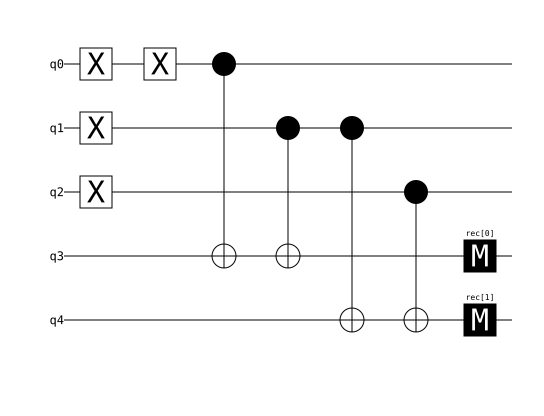

In [2]:
example_circuit.diagram("timeline-svg")

**Annotating every qubit in the diagram above:**

| Qubit | Role |
|---|---|
| 0 | data — part of the encoded logical qubit; participates in the $Z_0Z_1$ check |
| 1 | data — participates in **both** checks ($Z_0Z_1$ and $Z_1Z_2$); this is what lets the pair of syndrome bits distinguish $X_0$ from $X_1$ from $X_2$ (notebook 03, Section 4) |
| 2 | data — participates in the $Z_1Z_2$ check |
| 3 | ancilla — entangled with qubits 0 and 1, then measured; its outcome is the $Z_0Z_1$ syndrome bit |
| 4 | ancilla — entangled with qubits 1 and 2, then measured; its outcome is the $Z_1Z_2$ syndrome bit |

Notice qubits 0, 1, 2 have no `M` on their line in this diagram — by design, they are never measured.

### Prediction 1

**Before running the next cell:** the circuit above has `error_qubits=(0,)`, i.e. an $X_0$ error on $|1_L\rangle$. What do you expect the two ancilla measurement outcomes to be? (Compare with notebook 03's `X0` row: syndrome $(1, 0)$.)

In [3]:
bits = example_circuit.compile_sampler().sample(shots=1)[0]
print("Ancilla 3 (Z0Z1 syndrome bit):", int(bits[0]))
print("Ancilla 4 (Z1Z2 syndrome bit):", int(bits[1]))

Ancilla 3 (Z0Z1 syndrome bit): 1
Ancilla 4 (Z1Z2 syndrome bit): 0


## 4. Convention: measurement bit → stabilizer eigenvalue

Stim's `M` instruction returns `0` for the $|0\rangle$ outcome and `1` for the $|1\rangle$ outcome. With the CNOT-into-ancilla construction above, the ancilla ends up in $|0\rangle$ when the data-qubit parity is even (eigenvalue $+1$) and $|1\rangle$ when the parity is odd (eigenvalue $-1$). So:

$$\text{ancilla measurement} = 0 \;\Longleftrightarrow\; \text{eigenvalue} = +1 \;\Longleftrightarrow\; \text{stabilizer satisfied}$$
$$\text{ancilla measurement} = 1 \;\Longleftrightarrow\; \text{eigenvalue} = -1 \;\Longleftrightarrow\; \text{stabilizer violated}$$

This is exactly the syndrome-bit convention notebook 03 used (Section 5), now produced by an actual measurement instead of a matrix computation.

### Prediction 2

**Before running the next cell:** for each of `no error`, $X_0$, $X_1$, $X_2$, predict the pair of ancilla outcomes. Which two cases, if any, do you expect to share a syndrome? (Recall notebook 03's answer: none — all four are distinct once both checks are combined.)

In [4]:
cases = {
    "no error": (),
    "X0": (0,),
    "X1": (1,),
    "X2": (2,),
}

header = f"{'case':<10} {'ancilla 3':>10} {'ancilla 4':>10} {'syndrome':>10}"
print(header)
print("-" * len(header))
for label, error_qubits in cases.items():
    circuit = syndrome_circuit(logical_bit=1, error_qubits=error_qubits)
    bits = circuit.compile_sampler().sample(shots=1)[0]
    a3, a4 = int(bits[0]), int(bits[1])
    print(f"{label:<10} {a3:>10} {a4:>10} {str((a3, a4)):>10}")

case        ancilla 3  ancilla 4   syndrome
-------------------------------------------
no error            0          0     (0, 0)
X0                  1          0     (1, 0)
X1                  1          1     (1, 1)
X2                  0          1     (0, 1)


This table matches notebook 03's syndrome table exactly: `(0,0)`, `(1,0)`, `(1,1)`, `(0,1)` for `no error`, $X_0$, $X_1$, $X_2$ respectively — now obtained purely from ancilla measurements, with the data qubits never touched.

## 5. Extraction, decoding, and correction are three different steps

It is easy to blur these together; keep them separate:

- **Syndrome extraction** (this notebook): run a circuit, measure ancillas, get a bit string like $(1, 1)$. This step produces *only* the syndrome — no claim yet about which qubit is wrong.
- **Decoding**: given a syndrome, guess which error (if any) most likely caused it. Notebook 03's `matrix_syndrome` table doubles as a lookup-table decoder here — syndrome $(1,1) \to$ "qubit 1 flipped" — but a decoder is a separate piece of logic from the circuit that produced the syndrome, and it gets much more interesting once measurements are noisy (notebook 05).
- **Correction**: given the decoder's guess, apply the fix (e.g. another `X` on the guessed qubit). This notebook does not apply any correction — it only extracts and reports the syndrome.

Under the idealized, noise-free assumptions used here, decoding this code is just the lookup table above. Notebook 05 asks a harder, more realistic question: what happens when the *physical qubits themselves* are noisy, so the same error pattern doesn't occur every time?

### Prediction 3

**Before running the next cell:** suppose *two* data qubits flip simultaneously, $X_0$ **and** $X_2$. Using the per-check logic (Section 3's annotation table — qubit 1 is shared between both checks, qubits 0 and 2 are each in only one), what syndrome do you expect? Is it the same as any single-qubit error's syndrome?

In [5]:
circuit = syndrome_circuit(logical_bit=1, error_qubits=(0, 2))
bits = circuit.compile_sampler().sample(shots=1)[0]
print("X0 and X2 together:", (int(bits[0]), int(bits[1])))
print("X1 alone, for comparison: (1, 1)")

X0 and X2 together: (1, 1)
X1 alone, for comparison: (1, 1)


The two-error case $X_0, X_2$ produces the **same** syndrome, $(1,1)$, as the single-error case $X_1$. A lookup-table decoder cannot tell these apart — it would "correct" a double error by (wrongly) flipping qubit 1, turning a 2-error event into a 3-error event. This is not a bug in the circuit; it is a direct consequence of code distance 3 (notebook 02): the code guarantees correct decoding only for *single*-qubit errors, and this is exactly what such a syndrome collision looks like in the quantum picture.

## 6. Scope of this notebook

This circuit is deliberately idealized, not a fully fault-tolerant syndrome-extraction circuit:

- Errors are injected as instantaneous, noise-free `X` gates chosen by us — real physical errors occur stochastically during every gate, including the CNOTs and measurements used to extract the syndrome itself.
- The ancillas here are assumed to measure perfectly. A noisy ancilla measurement can report the wrong syndrome bit even with no data-qubit error present — a case this notebook does not model.
- The circuit runs for a single round. Realistic QEC repeats syndrome extraction over many rounds and compares outcomes across rounds to filter out measurement noise.

Notebook 05 introduces physical noise explicitly and studies how a decoder's failure rate behaves as that noise increases.

## 7. TODO exercises

**TODO 1:** Confirm that the syndrome table does not depend on which logical bit was encoded — i.e. that stabilizer measurement really does not leak the logical value (notebook 03, Section 2). Loop over `logical_bit in (0, 1)` and, for each of the four `cases` above, print the resulting `(a3, a4)` syndrome. You should see the same four syndromes for both logical bits.

In [6]:
# TODO: loop over logical_bit in (0, 1) and the four cases, printing the syndrome for each.
# for logical_bit in (0, 1):
#     for label, error_qubits in cases.items():
#         circuit = syndrome_circuit(logical_bit=logical_bit, error_qubits=error_qubits)
#         bits = circuit.compile_sampler().sample(shots=1)[0]
#         print(logical_bit, label, (int(bits[0]), int(bits[1])))


**TODO 2:** Section 5 showed that $X_0 + X_2$ collides with $X_1$ alone. Are there any *other* two-qubit error combinations reachable on 3 qubits? Try $X_0 + X_1$ and $X_1 + X_2$ and print their syndromes. Do either of these collide with a *single*-qubit error's syndrome, or with `no error`?

In [7]:
# TODO: build syndrome_circuit(logical_bit=1, error_qubits=(0, 1)) and (1, 2), sample each,
# and compare the resulting syndromes against the single-error rows in `cases`.


## 8. Closed-notebook recall checklist

Close this notebook (or at least stop scrolling up) and answer these from memory:

1. What is an ancilla qubit, and why is it measured instead of the data qubits?
2. Which qubit(s) does ancilla 3 entangle with, and which stabilizer does it report?
3. What Stim measurement outcome corresponds to stabilizer eigenvalue $-1$?
4. In your own words, what is the difference between syndrome extraction, decoding, and correction?
5. Why is this notebook's circuit not yet a fully fault-tolerant syndrome-extraction circuit?

If any of these feel shaky, re-read the matching section above before moving on.

## My Notes and Answers

<!-- PROTECTED:BEGIN -->
**This section is owned by the notebook's author. Automated edits (including future AI-assisted notebook updates) must not alter or remove anything between the PROTECTED markers below.**

### Prediction 1

*(your answer here)*

### Prediction 2

*(your answer here)*

### Prediction 3

*(your answer here)*

### TODO 1 notes

*(your answer here)*

### TODO 2 notes

*(your answer here)*

### Closed-notebook checklist answers

1.
2.
3.
4.
5.

<!-- PROTECTED:END -->